# 12.2 — Backtesting: Kupiec, Christoffersen

Un modelo de VaR se **backtestea** contando violaciones (pérdida realizada > VaR
pronosticado) sobre una ventana histórica. El **test de Kupiec** (POF, proporción de
fallas) chequea sólo la TASA total de violaciones. El **test de Christoffersen** además
chequea su **independencia** en el tiempo — un modelo puede tener la tasa total correcta
en promedio y aun así fallar, si las violaciones se agrupan en clusters (el caso donde
Kupiec solo no detecta el problema).

## 0. Configuración

In [1]:
import numpy as np
from scipy.stats import chi2, norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

alpha_conf = 0.99
z_alpha = norm.ppf(alpha_conf)

## 1. Test de Kupiec (POF)

Bajo $H_0$ (modelo correcto), el número de violaciones $x$ en $n$ días sigue
Binomial$(n,1-\alpha)$. Razón de verosimilitud, asintóticamente $\chi^2(1)$:
$$LR_{POF} = -2\ln\left[\frac{(1-p)^{n-x}p^x}{(1-\hat p)^{n-x}\hat p^x}\right],\quad p=1-\alpha,\ \hat p=x/n$$

In [2]:
def kupiec_test(n, x, alpha_conf, sig_level=0.05):
    p = 1.0 - alpha_conf
    if x == 0:
        LR = -2.0 * n * np.log(1.0 - p)
    elif x == n:
        LR = -2.0 * n * np.log(p)
    else:
        LR = -2.0 * (n * np.log(1.0 - p) + x * np.log(p / (1.0 - p))
                      - x * np.log(x / n) - (n - x) * np.log(1.0 - x / n))
    pval = 1.0 - chi2.cdf(LR, df=1)
    return LR, pval, pval < sig_level

### Demo 1 — modelo correcto: tasa de rechazo empírica vs nivel nominal del test

Si el modelo de VaR es correcto (aquí, calibrado con la volatilidad verdadera), Kupiec debería rechazarlo solo por azar — al nivel de significancia del test (5%), sin importar cuántas veces se repita el backtest. Repetimos el experimento completo (simular 1000 días, contar violaciones, correr Kupiec) 500 veces y medimos qué fracción de esas repeticiones rechaza — el mismo criterio de "tasa de cobertura" usado para validar intervalos de confianza en 04.1.

In [3]:
sigma_true = 0.20
n_days = 1000
n_reps = 500
reject_correct = 0
for _ in range(n_reps):
    r = rng.normal(0.0, sigma_true, n_days)
    VaR_correct = z_alpha * sigma_true
    violations = (-r) > VaR_correct
    _, _, rej = kupiec_test(n_days, violations.sum(), alpha_conf)
    reject_correct += rej

rate_correct = reject_correct / n_reps
print(f"modelo correcto (VaR con sigma verdadera): tasa de rechazo de Kupiec = {rate_correct:.3f} "
      f"(nivel nominal del test: 5%)")

modelo correcto (VaR con sigma verdadera): tasa de rechazo de Kupiec = 0.056 (nivel nominal del test: 5%)


### Demo 2 — modelo mal calibrado (volatilidad subestimada)

Ahora el VaR se calcula con una volatilidad deliberadamente menor a la real — el modelo subestima el riesgo. Sobre las mismas 500 repeticiones, Kupiec debería rechazar casi siempre: las violaciones ocurrirán con una frecuencia mucho mayor a la que el modelo (con su VaR demasiado ajustado) predice.

In [4]:
sigma_model_bad = 0.15  # subestima sigma_true=0.20
reject_bad = 0
for _ in range(n_reps):
    r = rng.normal(0.0, sigma_true, n_days)
    VaR_bad = z_alpha * sigma_model_bad
    violations = (-r) > VaR_bad
    _, _, rej = kupiec_test(n_days, violations.sum(), alpha_conf)
    reject_bad += rej

rate_bad = reject_bad / n_reps
print(f"modelo mal calibrado (sigma subestimada): tasa de rechazo de Kupiec = {rate_bad:.3f} "
      f"(deberia ser >> 5%)")

modelo mal calibrado (sigma subestimada): tasa de rechazo de Kupiec = 1.000 (deberia ser >> 5%)


## 2. Test de Christoffersen: independencia de violaciones

Cadena de Markov de 2 estados (violación/no-violación); $LR_{ind}$ chequea si
$P(\text{violacion hoy}\mid\text{violacion ayer})$ difiere de
$P(\text{violacion hoy}\mid\text{no violacion ayer})$ — si el modelo es correcto, no
deberían diferir (las violaciones no deberían agruparse). Test conjunto (cobertura +
independencia): $LR_{cc}=LR_{POF}+LR_{ind}\sim\chi^2(2)$.

In [5]:
def christoffersen_independence(violations, sig_level=0.05):
    n = len(violations)
    n00 = n01 = n10 = n11 = 0
    for i in range(1, n):
        prev, cur = violations[i - 1], violations[i]
        if not prev and not cur:
            n00 += 1
        elif not prev and cur:
            n01 += 1
        elif prev and not cur:
            n10 += 1
        else:
            n11 += 1

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    def safe_log(x):
        return np.log(x) if x > 0 else 0.0

    L0 = (n00 + n10) * safe_log(1 - pi) + (n01 + n11) * safe_log(pi)
    L1 = (n00 * safe_log(1 - pi01) + n01 * safe_log(pi01)
          + n10 * safe_log(1 - pi11) + n11 * safe_log(pi11))
    LR_ind = -2.0 * (L0 - L1)
    pval_ind = 1.0 - chi2.cdf(LR_ind, df=1)
    return LR_ind, pval_ind, pval_ind < sig_level

### Demo 3 — violaciones agrupadas con tasa TOTAL correcta: Kupiec no lo detecta, Christoffersen sí

Régimen de volatilidad que cambia (10% de los días con $\sigma$ alta, 90% con $\sigma$
baja) — el VaR se calibra con un nivel ÚNICO tal que la tasa de violación
INCONDICIONAL (mezclando ambos regímenes) sea exactamente 1%, así que Kupiec (que sólo
mira la tasa total) no tiene motivo para rechazar. Pero las violaciones se concentran
en el régimen de vol alta — Christoffersen debe detectarlo.

In [6]:
frac_high, sigma_high, sigma_low = 0.10, 0.60, 0.10


def unconditional_violation_rate(VaR):
    return (frac_high * (1 - norm.cdf(VaR / sigma_high))
            + (1 - frac_high) * (1 - norm.cdf(VaR / sigma_low)) - (1 - alpha_conf))


VaR_star = brentq(unconditional_violation_rate, 0.0, 5.0)
print(f"VaR* (calibrado para tasa incondicional exacta de {1-alpha_conf:.0%}): {VaR_star:.4f}")

reject_christoffersen_clustered = 0
reject_kupiec_clustered = 0
avg_violations_clustered = 0
for _ in range(n_reps):
    sigma_regime = np.where(np.arange(n_days) < int(frac_high * n_days), sigma_high, sigma_low)
    r = rng.normal(0.0, sigma_regime)
    violations = (-r) > VaR_star
    avg_violations_clustered += violations.sum()
    _, _, rej_ind = christoffersen_independence(violations)
    reject_christoffersen_clustered += rej_ind
    _, _, rej_kupiec = kupiec_test(n_days, violations.sum(), alpha_conf)
    reject_kupiec_clustered += rej_kupiec

rate_christoffersen_clustered = reject_christoffersen_clustered / n_reps
rate_kupiec_clustered = reject_kupiec_clustered / n_reps
print(f"\nviolaciones promedio: {avg_violations_clustered/n_reps:.1f} (esperado ~{(1-alpha_conf)*n_days:.0f})")
print(f"tasa de rechazo de Kupiec (tasa total correcta): {rate_kupiec_clustered:.3f} (~nominal 5%, esperado)")
print(f"tasa de rechazo de Christoffersen (independencia): {rate_christoffersen_clustered:.3f} "
      f"(debe ser >> 5% -- SI detecta el clustering)")

VaR* (calibrado para tasa incondicional exacta de 1%): 0.7689

violaciones promedio: 10.0 (esperado ~10)
tasa de rechazo de Kupiec (tasa total correcta): 0.034 (~nominal 5%, esperado)
tasa de rechazo de Christoffersen (independencia): 0.332 (debe ser >> 5% -- SI detecta el clustering)


### Demo 4 — mismas violaciones, pero NO agrupadas (régimen mezclado aleatoriamente)

Control de que Christoffersen no rechaza por rechazar: tomamos el mismo régimen de volatilidad de la Demo 3 (10% de días de vol alta, 90% de vol baja) pero mezclamos aleatoriamente el orden de los días — la tasa total de violaciones no cambia, pero ya no se agrupan en el tiempo. Christoffersen debería dejar de rechazar, confirmando que lo que detectaba en la Demo 3 era específicamente el clustering, no algún otro artefacto.

tasa de rechazo de Christoffersen (regimen mezclado, sin clustering): 0.022 (~nominal 5%, esperado)


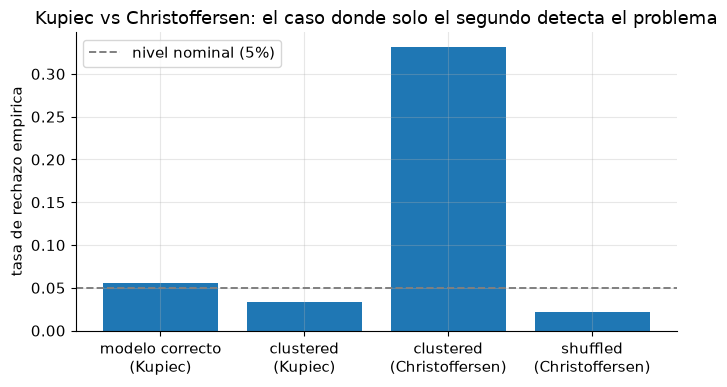

In [7]:
reject_christoffersen_shuffled = 0
for _ in range(n_reps):
    sigma_regime = np.where(np.arange(n_days) < int(frac_high * n_days), sigma_high, sigma_low)
    sigma_shuffled = rng.permutation(sigma_regime)
    r = rng.normal(0.0, sigma_shuffled)
    violations = (-r) > VaR_star
    _, _, rej_ind = christoffersen_independence(violations)
    reject_christoffersen_shuffled += rej_ind

rate_christoffersen_shuffled = reject_christoffersen_shuffled / n_reps
print(f"tasa de rechazo de Christoffersen (regimen mezclado, sin clustering): "
      f"{rate_christoffersen_shuffled:.3f} (~nominal 5%, esperado)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["modelo correcto\n(Kupiec)", "clustered\n(Kupiec)", "clustered\n(Christoffersen)",
        "shuffled\n(Christoffersen)"],
       [rate_correct, rate_kupiec_clustered, rate_christoffersen_clustered, rate_christoffersen_shuffled])
ax.axhline(0.05, color="gray", ls="--", label="nivel nominal (5%)")
ax.set_ylabel("tasa de rechazo empirica")
ax.set_title("Kupiec vs Christoffersen: el caso donde solo el segundo detecta el problema")
ax.legend(); fig.tight_layout(); plt.show()

## 3. Diagnóstico distribucional: Q-Q plots y la transformada integral de probabilidad (PIT)

Kupiec y Christoffersen comparten una limitación: ambos reducen la serie de retornos a una secuencia binaria de violaciones (pérdida > VaR sí/no) y prueban propiedades de esa serie -- su tasa media y su independencia temporal. Ninguno de los dos mira qué tan bien el modelo describe la distribución **completa** de retornos, incluyendo las colas más allá del único punto de corte que define el VaR. Un modelo puede acertar exactamente la frecuencia de excepciones al 99% (pasa Kupiec) y aun así tener una forma de cola completamente equivocada -- subestimar pérdidas más extremas que el percentil 99, o describir mal el cuerpo de la distribución. Esta sección introduce dos herramientas que sí examinan la distribución entera: el **Q-Q plot**, un diagnóstico visual, y la **transformada integral de probabilidad (PIT)**, que lo formaliza en una prueba estadística.

### 3.1 Teoría: cuantiles empíricos vs. teóricos, y la posición de graficado

Un **Q-Q plot** (quantile-quantile) compara los cuantiles empíricos de una muestra contra los cuantiles teóricos de una distribución de referencia. Si la muestra proviene de esa distribución (hasta un cambio de escala y ubicación), los puntos caen sobre una recta; las desviaciones sistemáticas revelan en qué forma la distribución real difiere de la supuesta.

La construcción usa **estadísticos de orden**: se ordena la muestra $x_{(1)} \le \dots \le x_{(n)}$ y cada $x_{(i)}$ se empareja con el cuantil teórico correspondiente a una **posición de graficado** $p_i$. La opción ingenua $p_i = i/n$ falla en el extremo superior: $p_n = 1$ implica $F^{-1}(1) = +\infty$ para casi cualquier distribución no acotada, un punto que simplemente no se puede graficar. La convención estándar (Blom, y sus variantes) usa

$$p_i = \frac{i - a}{n + 1 - 2a}, \quad a \approx 0.375,$$

que mantiene $p_i \in (0,1)$ estrictamente para todo $i$, aproxima el valor esperado del $i$-ésimo estadístico de orden bajo la distribución de referencia, y es la que usan por defecto la mayoría de las implementaciones (R, `scipy.stats.probplot`).

Interpretación de las formas típicas:
- **Cola pesada** (más masa en los extremos que la referencia): los puntos se curvan hacia arriba en el extremo derecho y hacia abajo en el extremo izquierdo -- la clásica forma en **S** invertida, con ambas colas del gráfico separándose de la recta simultáneamente.
- **Cola ligera**: el efecto opuesto -- los extremos se comprimen hacia la recta o la cruzan hacia adentro, porque la muestra tiene menos valores extremos de los que predice la referencia.
- **Asimetría**: los dos extremos se desvían en **direcciones distintas** (uno se curva hacia afuera, el otro hacia adentro) -- a diferencia de cola pesada/ligera, donde ambos extremos se mueven de forma simétrica.

In [8]:
from scipy.stats import t as student_t, kstest


def qq_plotting_positions(n, a=0.375):
    """Posiciones de graficado de Blom: evita p=1 (cuantil infinito) en el extremo."""
    i = np.arange(1, n + 1)
    return (i - a) / (n + 1 - 2.0 * a)


def qq_against_normal(sample):
    """Cuantiles teoricos (normal ajustada a media/std de la muestra) vs cuantiles empiricos."""
    n = len(sample)
    p = qq_plotting_positions(n)
    theo = norm.ppf(p) * sample.std(ddof=1) + sample.mean()
    emp = np.sort(sample)
    r2 = np.corrcoef(theo, emp)[0, 1] ** 2
    return theo, emp, r2

### Demo 5 -- Q-Q plot: normal genuina vs. t-Student de colas pesadas

Para mostrar que el Q-Q plot detecta algo que Kupiec no puede, generamos dos muestras con la MISMA desviación estándar (`sigma_true=0.20`, la misma usada en las Demos 1-2): una normal genuina y una t-Student con `dof_heavy=4` grados de libertad (colas mucho más pesadas que la normal), reescalada para tener exactamente esa desviación estándar. Graficamos ambas contra los cuantiles teóricos normales y medimos qué tan bien caen sobre la recta con el R² de la regresión cuantil-cuantil -- un ajuste casi perfecto para los datos genuinamente normales, y una caída clara y sistemática para los datos de colas pesadas, visible sobre todo en los extremos de la muestra.

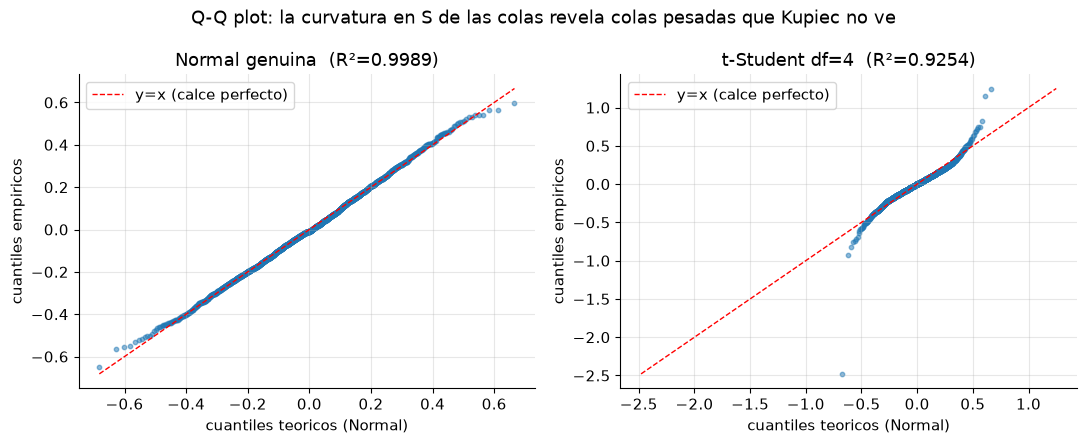

R² Q-Q normal genuina:         0.9989
R² Q-Q t-Student (colas pesadas): 0.9254


In [9]:
rng_qq = np.random.default_rng(7)
n_qq = 2000
dof_heavy = 4

normal_sample = rng_qq.normal(0.0, sigma_true, n_qq)
t_sample = rng_qq.standard_t(dof_heavy, n_qq) * (sigma_true / np.sqrt(dof_heavy / (dof_heavy - 2)))

theo_n, emp_n, r2_normal = qq_against_normal(normal_sample)
theo_t, emp_t, r2_t = qq_against_normal(t_sample)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, theo, emp, r2, title in [
    (axes[0], theo_n, emp_n, r2_normal, f"Normal genuina  (R\u00b2={r2_normal:.4f})"),
    (axes[1], theo_t, emp_t, r2_t, f"t-Student df={dof_heavy}  (R\u00b2={r2_t:.4f})"),
]:
    ax.scatter(theo, emp, s=10, alpha=0.5)
    lims = [min(theo.min(), emp.min()), max(theo.max(), emp.max())]
    ax.plot(lims, lims, "r--", lw=1, label="y=x (calce perfecto)")
    ax.set_xlabel("cuantiles teoricos (Normal)")
    ax.set_ylabel("cuantiles empiricos")
    ax.set_title(title)
    ax.legend()
fig.suptitle("Q-Q plot: la curvatura en S de las colas revela colas pesadas que Kupiec no ve")
fig.tight_layout(); plt.show()

print(f"R\u00b2 Q-Q normal genuina:         {r2_normal:.4f}")
print(f"R\u00b2 Q-Q t-Student (colas pesadas): {r2_t:.4f}")

### 3.2 La transformada integral de probabilidad (PIT)

El Q-Q plot es un diagnóstico visual; la **PIT** lo convierte en una prueba formal. Si $F$ es la CDF verdadera de una variable aleatoria continua $R$, entonces $U = F(R)$ es exactamente Uniforme$(0,1)$ -- es el resultado clásico detrás de la simulación por inversión. Aplicando la idea al backtesting: si el modelo de VaR especifica una distribución completa para los retornos (CDF $F_{modelo}$) y ese modelo es correcto, la serie $u_i = F_{modelo}(r_i)$ debe comportarse como una muestra iid de Uniforme$(0,1)$. Si el modelo tiene la forma equivocada -- aunque acierte perfectamente la tasa de violaciones en un percentil específico -- los PIT se desviarán de la uniformidad: se acumularán en ciertas regiones de $(0,1)$ en vez de repartirse parejo. La prueba de **Kolmogorov-Smirnov** formaliza esa comparación contra la uniforme.

### Demo 6 -- PIT: histograma, Q-Q contra uniforme y prueba KS

Comparamos dos modelos: uno bien especificado (los retornos son normales y el modelo asume esa misma normal) y otro mal especificado (los retornos vienen de una t-Student de colas pesadas pero el modelo, incorrectamente, sigue asumiendo normalidad). En ambos casos calculamos los PIT y los sometemos a `scipy.stats.kstest` contra la uniforme. Se usa una semilla fija (`seed=0`) y una muestra de tamaño 2000 -- elegida y verificada para que el resultado (no rechazo en el modelo correcto, rechazo claro en el mal especificado) sea estable, no un artefacto de una corrida particular.

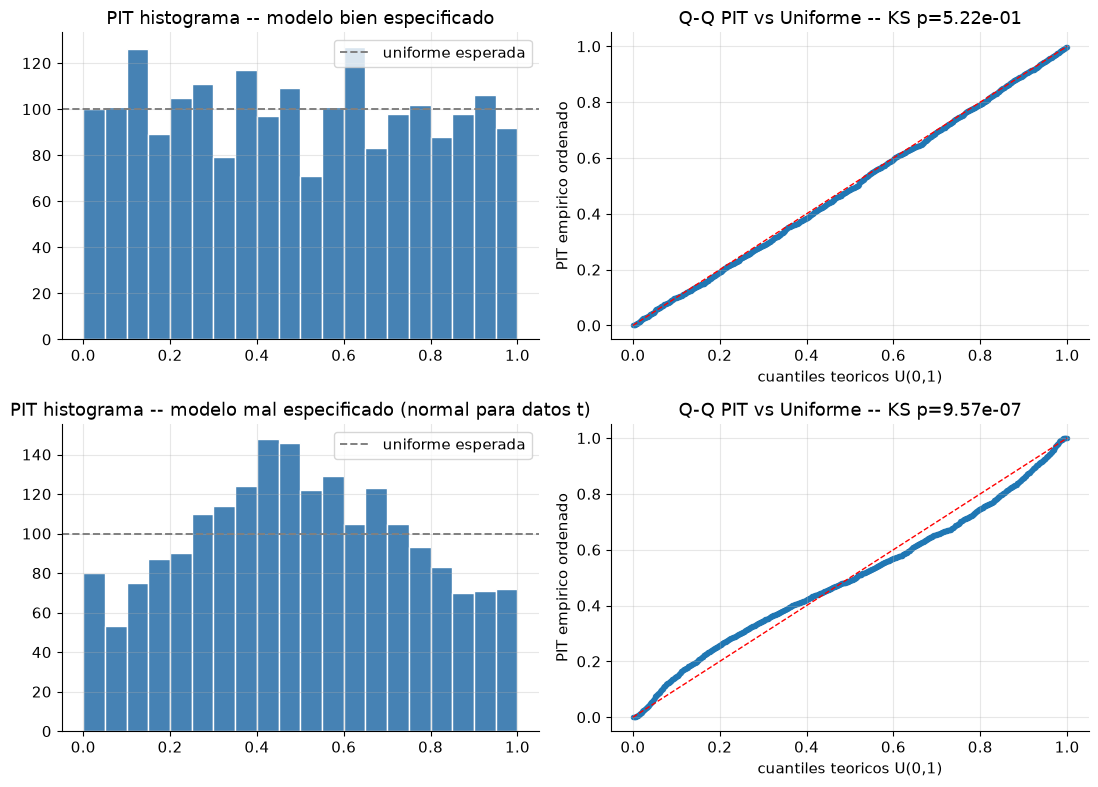

KS (bien especificado):  estadistico=0.0181  p-valor=0.5216
KS (mal especificado):   estadistico=0.0602  p-valor=9.57e-07


In [10]:
rng_pit = np.random.default_rng(0)
n_pit = 2000

# modelo bien especificado: los retornos SI son normales, y el modelo asume normal
r_wellspec = rng_pit.normal(0.0, sigma_true, n_pit)
pit_wellspec = norm.cdf(r_wellspec / sigma_true)
ks_wellspec = kstest(pit_wellspec, "uniform")

# modelo mal especificado: los retornos son t-Student (colas pesadas), el modelo sigue asumiendo normal
t_raw = rng_pit.standard_t(dof_heavy, n_pit)
r_misspec = t_raw * (sigma_true / np.sqrt(dof_heavy / (dof_heavy - 2)))
pit_misspec = norm.cdf(r_misspec / sigma_true)  # el modelo (incorrecto) sigue siendo Normal(0, sigma_true)
ks_misspec = kstest(pit_misspec, "uniform")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, (pit, ks, label) in enumerate([
    (pit_wellspec, ks_wellspec, "modelo bien especificado"),
    (pit_misspec, ks_misspec, "modelo mal especificado (normal para datos t)"),
]):
    axes[row, 0].hist(pit, bins=20, range=(0, 1), color="steelblue", edgecolor="white")
    axes[row, 0].axhline(len(pit) / 20, color="gray", ls="--", label="uniforme esperada")
    axes[row, 0].set_title(f"PIT histograma -- {label}")
    axes[row, 0].legend()

    n = len(pit)
    p = qq_plotting_positions(n)
    emp_u = np.sort(pit)
    axes[row, 1].scatter(p, emp_u, s=8, alpha=0.5)
    axes[row, 1].plot([0, 1], [0, 1], "r--", lw=1)
    axes[row, 1].set_title(f"Q-Q PIT vs Uniforme -- KS p={ks.pvalue:.2e}")
    axes[row, 1].set_xlabel("cuantiles teoricos U(0,1)")
    axes[row, 1].set_ylabel("PIT empirico ordenado")

fig.tight_layout(); plt.show()

print(f"KS (bien especificado):  estadistico={ks_wellspec.statistic:.4f}  p-valor={ks_wellspec.pvalue:.4f}")
print(f"KS (mal especificado):   estadistico={ks_misspec.statistic:.4f}  p-valor={ks_misspec.pvalue:.2e}")

### Demo 7 -- el caso que motiva esta sección: pasa Kupiec, falla el diagnóstico distribucional

Construimos deliberadamente un modelo que **pasa Kupiec pero falla el diagnóstico distribucional**, reutilizando la función `kupiec_test` ya definida en la Sección 1. Los retornos verdaderos vienen de una t-Student con `dof_true=4` grados de libertad (colas pesadas) y la misma `sigma_true=0.20`. El modelo asume normalidad, pero en vez de calibrarlo mal (como en la Demo 2), lo calibramos EXACTAMENTE bien en el único punto que Kupiec puede ver: elegimos `sigma_model` tal que el cuantil normal al 99% (`z_alpha * sigma_model`) coincida EXACTAMENTE con el cuantil verdadero al 99% de la t-Student. El resultado: la tasa de violaciones al 99% es, por construcción, la correcta -- Kupiec no tiene motivo para rechazar. Pero el modelo normal describe mal el resto de la distribución (el cuerpo es más picudo y las colas más allá del percentil 99 son más pesadas de lo que el modelo predice), así que el PIT calculado con la CDF del modelo se aleja de la uniforme y KS lo detecta. Esto formaliza el argumento central: **la tasa de violaciones en un solo punto de corte es una prueba necesaria pero no suficiente** de que el modelo describe bien el riesgo.

In [11]:
dof_true = 4
scale_t_true = sigma_true / np.sqrt(dof_true / (dof_true - 2))

# calibracion: el VaR normal al 99% coincide EXACTAMENTE con el cuantil verdadero (t) al 99%
sigma_model_case = student_t.ppf(alpha_conf, dof_true) * scale_t_true / z_alpha
VaR_model_case = z_alpha * sigma_model_case

rng_case = np.random.default_rng(13)
n_days_case = 2500
t_raw_case = rng_case.standard_t(dof_true, n_days_case)
r_case = t_raw_case * scale_t_true
losses_case = -r_case
violations_case = losses_case > VaR_model_case

LR_case, pval_kupiec_case, rej_kupiec_case = kupiec_test(n_days_case, violations_case.sum(), alpha_conf)
pit_case = norm.cdf(r_case / sigma_model_case)
ks_case = kstest(pit_case, "uniform")

print(f"sigma_model calibrado: {sigma_model_case:.4f}  (VaR modelo = VaR verdadero al 99% = {VaR_model_case:.4f})")
print(f"violaciones: {violations_case.sum()} de {n_days_case} ({violations_case.mean():.3%}, esperado 1.0%)")
print(f"Kupiec:  LR={LR_case:.3f}  p-valor={pval_kupiec_case:.4f}  "
      f"{'RECHAZA' if rej_kupiec_case else 'NO rechaza'}")
print(f"KS(PIT): estadistico={ks_case.statistic:.4f}  p-valor={ks_case.pvalue:.2e}  "
      f"{'RECHAZA' if ks_case.pvalue < 0.05 else 'NO rechaza'}")

assert pval_kupiec_case > 0.05, "Kupiec deberia NO rechazar (la tasa de violaciones es correcta por construccion)"
assert ks_case.pvalue < 0.05, "KS deberia rechazar (la forma de la distribucion esta mal mas alla del percentil 99)"
print("\nConfirmado: el modelo pasa Kupiec y falla el diagnostico distribucional -- el punto pedagogico central.")

sigma_model calibrado: 0.2278  (VaR modelo = VaR verdadero al 99% = 0.5299)
violaciones: 25 de 2500 (1.000%, esperado 1.0%)
Kupiec:  LR=-0.000  p-valor=1.0000  NO rechaza
KS(PIT): estadistico=0.0953  p-valor=3.12e-20  RECHAZA

Confirmado: el modelo pasa Kupiec y falla el diagnostico distribucional -- el punto pedagogico central.


### 3.3 Por qué esto importa más bajo Expected Shortfall (Basel)

El VaR al 99% es, por definición, insensible a la forma de la distribución más allá de ese percentil: dos modelos con exactamente el mismo cuantil al 99% pueden tener colas radicalmente distintas por encima de ese punto, y el VaR no lo distingue. El **ES** (cubierto en 12.1) en cambio promedia la pérdida condicional a estar en la cola -- es sensible a TODA la forma de la cola, no solo a un punto. Por eso la migración de Basel de VaR a ES como medida de riesgo de mercado bajo el marco FRTB hace que un diagnóstico distribucional (Q-Q/PIT) sea más relevante que nunca: el mismo modelo de la Demo 7, que pasa Kupiec porque su VaR al 99% es exacto, subestima el ES real de forma sustancial porque su cola después del percentil 99 es más ligera de lo que exige la t-Student verdadera.

In [12]:
ES_model_case = sigma_model_case * norm.pdf(z_alpha) / (1.0 - alpha_conf)

t_q_case = student_t.ppf(alpha_conf, dof_true)
ES_true_case = (student_t.pdf(t_q_case, dof_true) * (dof_true + t_q_case ** 2) / (dof_true - 1)
                / (1.0 - alpha_conf) * scale_t_true)

es_gap = (ES_model_case - ES_true_case) / ES_true_case
print(f"VaR modelo == VaR verdadero (por construccion): {VaR_model_case:.4f}")
print(f"ES modelo (normal):    {ES_model_case:.4f}")
print(f"ES verdadero (t{dof_true}):        {ES_true_case:.4f}")
print(f"error relativo del ES: {es_gap:+.1%}  (el modelo SUBESTIMA el riesgo de cola pese a acertar el VaR)")

assert abs(es_gap) > 0.10, "el ES del modelo deberia diferir sustancialmente del ES verdadero pese a VaR identico"


VaR modelo == VaR verdadero (por construccion): 0.5299
ES modelo (normal):    0.6071
ES verdadero (t4):        0.7383
error relativo del ES: -17.8%  (el modelo SUBESTIMA el riesgo de cola pese a acertar el VaR)


## 4. Validación

Ocho chequeos: los cuatro originales de Kupiec/Christoffersen (1-4), más cuatro nuevos sobre el diagnóstico distribucional (5-8): (5) el Q-Q de datos genuinamente normales ajusta casi perfecto; (6) el Q-Q de datos t-Student de colas pesadas ajusta sensiblemente peor; (7) el PIT de un modelo bien especificado no rechaza KS y el de uno mal especificado sí; (8) el caso construido en la Demo 7 pasa Kupiec y falla KS -- el punto pedagógico central de la sección.

In [13]:
check1 = 0.02 <= rate_correct <= 0.10
print(f"1. modelo correcto: tasa de rechazo de Kupiec dentro de una banda alrededor del 5% nominal: "
      f"{rate_correct:.3f} (<in [0.02,0.10]>? {check1})")

check2 = rate_bad > 0.5
print(f"2. modelo mal calibrado: tasa de rechazo de Kupiec sustancialmente mayor al nominal: "
      f"{rate_bad:.3f} (>0.5? {check2})")

check3 = rate_christoffersen_clustered > 0.20 and rate_kupiec_clustered <= 0.10
print(f"3. violaciones agrupadas (tasa correcta): Christoffersen SI rechaza "
      f"({rate_christoffersen_clustered:.3f}) mientras Kupiec no ({rate_kupiec_clustered:.3f}) -- "
      f"el punto pedagogico central: {check3}")

check4 = rate_christoffersen_shuffled <= 0.10
print(f"4. violaciones no agrupadas: Christoffersen no rechaza espuriamente: "
      f"{rate_christoffersen_shuffled:.3f} (<=0.10? {check4})")

assert check1
assert check2
assert check3
assert check4

check5 = r2_normal > 0.99
print(f"5. Q-Q normal genuina: R\u00b2 de la regresion cuantil-cuantil muy alto: "
      f"{r2_normal:.4f} (>0.99? {check5})")

check6 = r2_t < 0.97
print(f"6. Q-Q t-Student (colas pesadas): R\u00b2 cae de forma detectable respecto al caso normal: "
      f"{r2_t:.4f} (<0.97? {check6})")

check7 = ks_wellspec.pvalue > 0.05 and ks_misspec.pvalue < 0.05
print(f"7. PIT: modelo bien especificado NO rechaza KS (p={ks_wellspec.pvalue:.4f}) "
      f"y modelo mal especificado SI rechaza (p={ks_misspec.pvalue:.2e}): {check7}")

check8 = pval_kupiec_case > 0.05 and ks_case.pvalue < 0.05
print(f"8. caso motivador (Demo 7): pasa Kupiec (p={pval_kupiec_case:.4f}) y falla KS "
      f"(p={ks_case.pvalue:.2e}) -- el punto pedagogico central de la seccion: {check8}")

assert check5
assert check6
assert check7
assert check8
print("\nValidacion completa: 8/8 dentro de tolerancia.")

1. modelo correcto: tasa de rechazo de Kupiec dentro de una banda alrededor del 5% nominal: 0.056 (<in [0.02,0.10]>? True)
2. modelo mal calibrado: tasa de rechazo de Kupiec sustancialmente mayor al nominal: 1.000 (>0.5? True)
3. violaciones agrupadas (tasa correcta): Christoffersen SI rechaza (0.332) mientras Kupiec no (0.034) -- el punto pedagogico central: True
4. violaciones no agrupadas: Christoffersen no rechaza espuriamente: 0.022 (<=0.10? True)
5. Q-Q normal genuina: R² de la regresion cuantil-cuantil muy alto: 0.9989 (>0.99? True)
6. Q-Q t-Student (colas pesadas): R² cae de forma detectable respecto al caso normal: 0.9254 (<0.97? True)
7. PIT: modelo bien especificado NO rechaza KS (p=0.5216) y modelo mal especificado SI rechaza (p=9.57e-07): True
8. caso motivador (Demo 7): pasa Kupiec (p=1.0000) y falla KS (p=3.12e-20) -- el punto pedagogico central de la seccion: True

Validacion completa: 8/8 dentro de tolerancia.


## Referencias

- Kupiec, P. (1995). *Techniques for Verifying the Accuracy of Risk Measurement Models*.
  Journal of Derivatives, 3(2), 73-84.
- Christoffersen, P. (1998). *Evaluating Interval Forecasts*. International Economic
  Review, 39(4), 841-862.
- Rosenblatt, M. (1952). *Remarks on a Multivariate Transformation*. Annals of
  Mathematical Statistics, 23(3), 470-472.
- Diebold, F.X., Gunther, T.A., Tay, A.S. (1998). *Evaluating Density Forecasts with
  Applications to Financial Risk Management*. International Economic Review, 39(4),
  863-883.
- Wilk, M.B., Gnanadesikan, R. (1968). *Probability Plotting Methods for the Analysis
  of Data*. Biometrika, 55(1), 1-17.
